Data available at: https://www.kaggle.com/datasets/tunguz/online-retail


In [1]:
# import main libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('../data/Online Retail.xlsx', header=0)
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
columns = ['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']
df.columns = columns
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['customer_id'] = df['customer_id'].astype("Int64")
df.head(20)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    541909 non-null  object        
 1   stock_code    541909 non-null  object        
 2   description   540455 non-null  object        
 3   quantity      541909 non-null  int64         
 4   invoice_date  541909 non-null  datetime64[ns]
 5   unit_price    541909 non-null  float64       
 6   customer_id   406829 non-null  Int64         
 7   country       541909 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 33.6+ MB


Report from the source about the variables:

- InvoiceNo: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.
- StockCode: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.
- Description: Product (item) name. Nominal.
- Quantity: The quantities of each product (item) per transaction. Numeric.
- InvoiceDate: Invice Date and time. Numeric, the day and time when each transaction was generated.
- UnitPrice: Unit price. Numeric, Product price per unit in sterling.
- CustomerID: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.
- Country: Country name. Nominal, the name of the country where each customer resides.

In [58]:
# Number of invoices
print(f"Number of invoices {df['invoice_no'].nunique()}")
print(f"Proportion of invoices {round(df['invoice_no'].nunique() / (len(df)) * 100, 2)} % out of total purchases")

# Number of custormers
print(f"Number of custormers {df['customer_id'].nunique()}")
print(f"Proportion of custormers {round(df['customer_id'].nunique() / (len(df)) * 100, 2)} % out of total purchases")

# Number of rows without customer_id
print(f"Number of rows without customer id {df['customer_id'].isna().sum()}")
print(f"Proportion of rows without customer id {round(df['customer_id'].isna().mean() * 100, 2)} % out of total purchases")

Number of invoices 25900
Proportion of invoices 4.78 % out of total purchases
Number of custormers 4372
Proportion of custormers 0.81 % out of total purchases
Number of rows without customer id 135080
Proportion of rows without customer id 24.93 % out of total purchases


Just 4372 customers (no considering nulls) represent 5419090 purchases in 25900 invoices. Therefore, customers make repeat purchases and always buy several items each time, on average.

Almost 25 % of the dataset does not have customer_id

In [6]:
print(f"Number of stock codes {df['stock_code'].nunique()}")
print(f"Number of description {df['description'].nunique()}")

Number of stock codes 4070
Number of description 4223


The dataset does not have the same number of stock codes than description. Let's dive deeper on that

In [23]:
multiple_descriptions = df.groupby('stock_code')['description'].nunique(dropna=False)
stock_codes_multiple = multiple_descriptions[multiple_descriptions > 1].sort_values(ascending=False)
print(f"Stock codes with multiple descriptions: {len(stock_codes_multiple)}")
stock_codes_multiple.head()

Stock codes with multiple descriptions: 1324


stock_code
20713    9
23084    8
85175    7
21830    7
23131    6
Name: description, dtype: int64

In [8]:
# See the descriptions of top 5 stock_codes with more descriptions
for stock_code in stock_codes_multiple.head(5).index:
    descriptions = df[df['stock_code'] == stock_code]['description'].unique()
    print(f"\n{stock_code}: {len(descriptions)} descripciones")
    for desc in descriptions:
        print(f"  - {desc}")


20713: 9 descripciones
  - JUMBO BAG OWLS
  - nan
  - wrongly marked. 23343 in box
  - wrongly coded-23343
  - found
  - Found
  - wrongly marked 23343
  - Marked as 23343
  - wrongly coded 23343

23084: 8 descripciones
  - RABBIT NIGHT LIGHT
  - nan
  - temp adjustment
  - allocate stock for dotcom orders ta
  - add stock to allocate online orders
  - for online retail orders
  - Amazon
  - website fixed

85175: 7 descripciones
  - CACTI T-LIGHT CANDLES
  - Amazon sold sets
  - dotcom sold sets
  - wrongly sold sets
  - ? sold as sets?
  - check
  - nan

21830: 7 descripciones
  - ASSORTED CREEPY CRAWLIES
  - MERCHANT CHANDLER CREDIT ERROR, STO
  - sold as 1
  - ?
  - damaged
  - OOPS ! adjustment
  - nan

23131: 6 descripciones
  - MISTLETOE HEART WREATH CREAM
  - MISELTOE HEART WREATH WHITE
  - MISELTOE HEART WREATH CREAM
  - ?
  - had been put aside
  - nan


Different descriptions are used for some stock codes to somo failures when marking them or sime other kind o of problems when stocktaking. Therefore, we consider stock codes as the main variable to differentiate items. It also ease the problem as no nulls are recorded in stock_code feature

In [9]:
print('Purchases come from', df['country'].nunique(), 'different countries')
df['country'].value_counts()

Purchases come from 38 different countries


country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


Purchases come mainly from UK and then from european countries. It exists a label 'Unspecified' with 446 purchases 

In [10]:
df[['quantity', 'unit_price']].describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
unit_price,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0


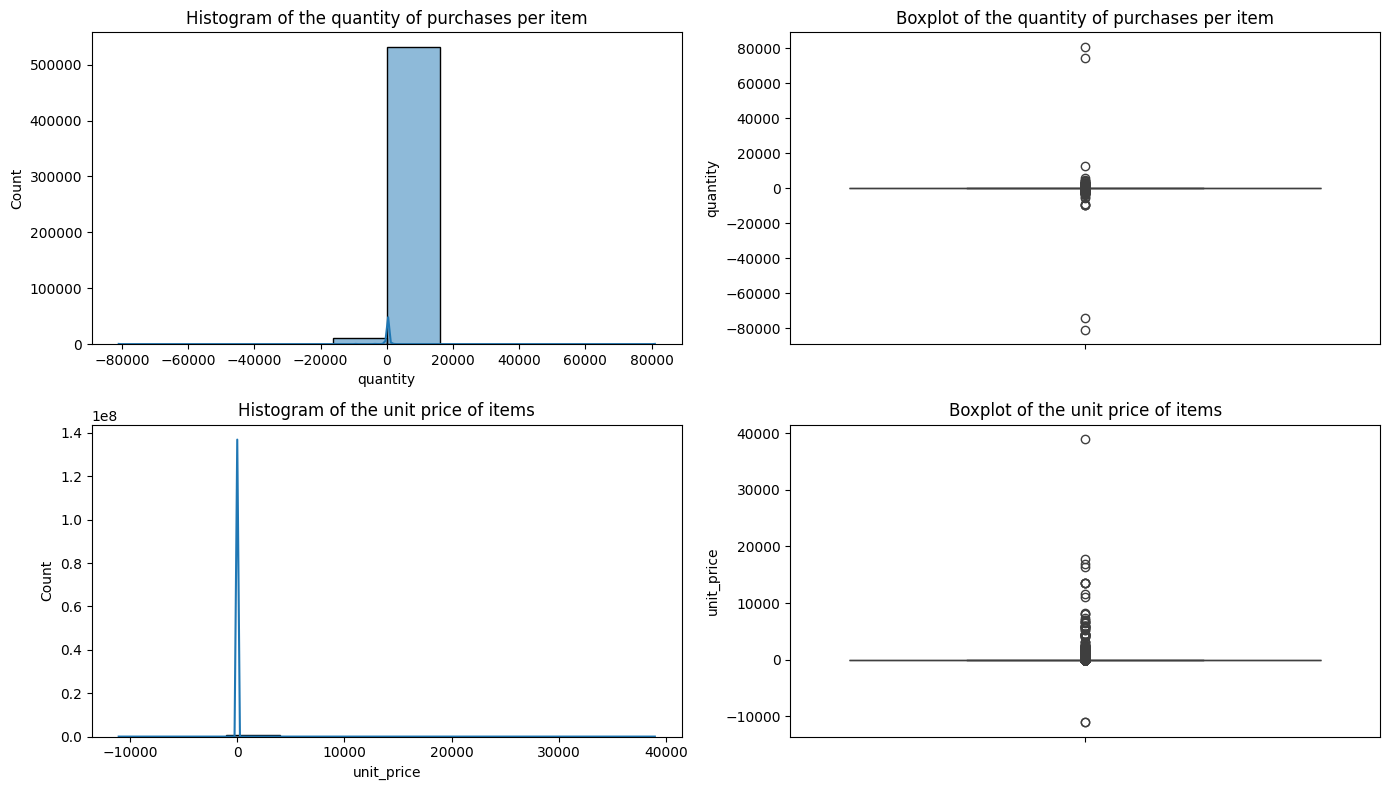

In [11]:
plt.figure(figsize=(14,8))
plt.subplot(2,2,1)
sns.histplot(data=df, x='quantity', bins=10, kde=True)
plt.title('Histogram of the quantity of purchases per item')

plt.subplot(2,2,2)
sns.boxplot(data=df, y='quantity')
plt.title('Boxplot of the quantity of purchases per item')

plt.subplot(2,2,3)
sns.histplot(data=df, x='unit_price', bins=10, kde=True)
plt.title('Histogram of the unit price of items')

plt.subplot(2,2,4)
sns.boxplot(data=df, y='unit_price')
plt.title('Boxplot of the unit price of items')
plt.tight_layout()
plt.show()

These plots do not show much as both variables are concentrated within a very narrow range (1-10 for quantity and 1.25-4.13 for unit_price) while several outliers appear with values much bigger than that range. Both variables show negative values so let's explore that

In [12]:
df[df['quantity'] < 0].sort_values(by='quantity', ascending=True).head(20)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom
225529,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,<NA>,United Kingdom
225530,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,<NA>,United Kingdom
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838,United Kingdom
225528,556687,23003,Printing smudges/thrown away,-9058,2011-06-14 10:36:00,0.00,<NA>,United Kingdom
115818,546152,72140F,throw away,-5368,2011-03-09 17:25:00,0.00,<NA>,United Kingdom
431381,573596,79323W,"Unsaleable, destroyed.",-4830,2011-10-31 15:17:00,0.00,<NA>,United Kingdom
341601,566768,16045,NaN,-3667,2011-09-14 17:53:00,0.00,<NA>,United Kingdom
323458,565304,16259,NaN,-3167,2011-09-02 12:18:00,0.00,<NA>,United Kingdom


Through descriptions it is seen that negative quantities with unit_price 0 and no customer_id represent elimination of the item from inventory due to unusability, which leads to destroyment or disposal. 

On the other hand, cases where there is a positive unit price seem to be regular returns of the product from the customer. Moreover, theses cases seem to have a different invoice number, starting with C

In [45]:
display(df[df['invoice_no'].astype(str).str.startswith('C')].sort_values(by='quantity', ascending=False).head(20))


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
1441,C536543,22632,HAND WARMER RED RETROSPOT,-1,2010-12-01 14:30:00,2.10,17841,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom
297546,C562953,22328,ROUND SNACK BOXES SET OF 4 FRUITS,-1,2011-08-11 10:12:00,2.95,16180,United Kingdom
297547,C562953,22697,GREEN REGENCY TEACUP AND SAUCER,-1,2011-08-11 10:12:00,2.95,16180,United Kingdom
297548,C562954,20914,SET/5 RED RETROSPOT LID GLASS BOWLS,-1,2011-08-11 10:13:00,2.95,17429,United Kingdom
297905,C562956,22637,PIGGY BANK RETROSPOT,-1,2011-08-11 10:14:00,2.55,13186,United Kingdom
297906,C562957,22842,BISCUIT TIN VINTAGE RED,-1,2011-08-11 10:15:00,6.75,13319,United Kingdom
297907,C562957,22540,MINI JIGSAW CIRCUS PARADE,-1,2011-08-11 10:15:00,0.42,13319,United Kingdom
297908,C562958,M,Manual,-1,2011-08-11 10:19:00,3.25,17531,United Kingdom
297528,C562952,23110,PARISIENNE KEY CABINET,-1,2011-08-11 10:10:00,5.75,12749,United Kingdom


In [47]:
display(df[df['stock_code'].astype(str).str.strip().isin(['M', 'D'])].head(20))


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274,United Kingdom
2250,536569,M,Manual,1,2010-12-01 15:35:00,18.95,16274,United Kingdom
5684,536865,M,Manual,1,2010-12-03 11:28:00,2.55,<NA>,United Kingdom
6798,536981,M,Manual,2,2010-12-03 14:26:00,0.85,14723,United Kingdom
7976,537077,M,Manual,12,2010-12-05 11:59:00,0.42,17062,United Kingdom
8530,537137,M,Manual,36,2010-12-05 12:43:00,0.85,16327,United Kingdom
8587,537140,M,Manual,1,2010-12-05 12:53:00,0.42,12748,United Kingdom
8588,537140,M,Manual,1,2010-12-05 12:53:00,0.85,12748,United Kingdom
9038,C537164,D,Discount,-1,2010-12-05 13:21:00,29.29,14527,United Kingdom


Invoice numbers starting with C are always cases with negative quantities referring to returns or discounts applied to customers, whose stock_code are D or M. Nevertheless, the sotck_code Manual can also refer to adding products manually and not always eliminating

In [13]:
df[df['customer_id'].isna()][['quantity', 'unit_price']].describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,135080.0,1.995573,66.696153,-9600.00,1.00,1.00,3.00,5568.00
unit_price,135080.0,8.076577,151.900816,-11062.06,1.63,3.29,5.45,17836.46


Customer_id cannot be used to differentiate disposal/destroyment from real purchases as some NaN values are real unrecorded values

In [14]:
df[df['unit_price'] < 0].head(20)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,<NA>,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,<NA>,United Kingdom


Negative unit prices are used to adjust bad debts so they do not represent any pruchase

In [15]:
df[df['unit_price'] == 0].head(20)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,<NA>,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,<NA>,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,<NA>,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,<NA>,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,<NA>,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,<NA>,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,<NA>,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,<NA>,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,<NA>,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,<NA>,United Kingdom


This sample of cases where unit price is 0 shows a real problem of this dataset as there are cases where positive quantities do not have any price, customer id nor description so it is almost impossible to understand them. Even when they have short descriptions ('amazon') is hard to understand as they can be some movement of stocks from one site to another some gifts...

On the ohter hand, as it was said, negative quantities with 0 price are considered to be destroyment/disposal of items

Let's explore more about products

In [109]:
df['total_money'] = df['quantity'] * df['unit_price']
product_summary = df.groupby('stock_code').agg(
    description=('description', 'first'),
    total_quantity=('quantity', 'sum'),
    revenue=('total_money', 'sum'),
    customers=('customer_id', 'nunique'),
    invoices=('invoice_no', 'nunique')
).sort_values('revenue', ascending=False)

product_summary.head(10)

,description,total_quantity,revenue,customers,invoices
stock_code,,,,,
DOT,DOTCOM POSTAGE,1707,206245.48,1,710
22423,REGENCY CAKESTAND 3 TIER,12980,164762.19,887,2172
47566,PARTY BUNTING,18022,98302.98,708,1706
85123A,WHITE HANGING HEART T-LIGHT HOLDER,38830,97894.50,858,2246
85099B,JUMBO BAG RED RETROSPOT,47363,92356.03,636,2135
23084,RABBIT NIGHT LIGHT,30646,66756.59,450,1025
POST,POSTAGE,6353,66230.64,379,1254
22086,PAPER CHAIN KIT 50'S CHRISTMAS,18902,63791.94,615,1170
84879,ASSORTED COLOUR BIRD ORNAMENT,36221,58959.73,679,1468


In [105]:
no_digits = df[
    ~df['stock_code'].astype(str)
       .str.contains(r'\d', na=False)
]

no_digits['stock_code'].value_counts()



stock_code
POST            1256
DOT              710
M                571
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
PADS               4
B                  3
m                  1
Name: count, dtype: int64

In [106]:
unique_stock_desc = (
    no_digits[['stock_code', 'description']]
    .drop_duplicates()
    .sort_values(['stock_code', 'description'])
    .reset_index(drop=True)
)

unique_stock_desc

,stock_code,description
0,AMAZONFEE,AMAZON FEE
1,B,Adjust bad debt
2,BANK CHARGES,Bank Charges
3,CRUK,CRUK Commission
4,D,Discount
5,DCGSSBOY,BOYS PARTY BAG
6,DCGSSGIRL,GIRLS PARTY BAG
7,DOT,DOTCOM POSTAGE
8,DOT,NaN
9,M,Manual


It is clear that all this stock codes, except PADS, are not products so they do not contibute to this analysis. Let's analyse more about PADS as it could be a product

In [111]:
# Select all rows related to stock_code PADS
pads_rows = df[df['stock_code'] == 'PADS'].copy()

pads_rows

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,days_since_last_purchase,total_money
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-04-15 09:27:00,0.001,13952,United Kingdom,0.0,0.001
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-07-26 10:13:00,0.001,15618,United Kingdom,0.0,0.001
358655,568158,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 12:22:00,0.000,16133,United Kingdom,0.0,0.000
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 14:58:00,0.001,16198,United Kingdom,0.0,0.001


In [121]:
pads_invoice_numbers = pads_rows['invoice_no'].unique()

pads_invoice_context = df[df['invoice_no'].isin(pads_invoice_numbers)].copy()

pads_invoice_context[pads_invoice_context['description']
    .astype(str)
    .str.contains('PAD', case=False, na=False)]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,days_since_last_purchase,total_money
157167,550193,22354,RETROSPOT PADDED SEAT CUSHION,10,2011-04-15 09:27:00,3.750,13952,United Kingdom,0.0,37.500
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-04-15 09:27:00,0.001,13952,United Kingdom,0.0,0.001
157196,550193,46000R,POLYESTER FILLER PAD 45x30cm,8,2011-04-15 09:27:00,1.450,13952,United Kingdom,0.0,11.600
157197,550193,46000S,POLYESTER FILLER PAD 40x40cm,44,2011-04-15 09:27:00,1.450,13952,United Kingdom,0.0,63.800
157198,550193,46000M,POLYESTER FILLER PAD 45x45cm,8,2011-04-15 09:27:00,1.550,13952,United Kingdom,0.0,12.400
279043,561226,23300,GARDENERS KNEELING PAD CUP OF TEA,12,2011-07-26 10:13:00,1.650,15618,United Kingdom,0.0,19.800
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-07-26 10:13:00,0.001,15618,United Kingdom,0.0,0.001
358655,568158,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 12:22:00,0.000,16133,United Kingdom,0.0,0.000
358666,568158,46000S,POLYESTER FILLER PAD 40x40cm,4,2011-09-25 12:22:00,1.450,16133,United Kingdom,0.0,5.800
359860,568200,23301,GARDENERS KNEELING PAD KEEP CALM,12,2011-09-25 14:58:00,1.650,16198,United Kingdom,0.0,19.800


It seems to be a product but just complementary and it does not have a huge impact as its unit price is 0.001 which is not even a penny. Therefore, it can be treated as the rest of stock codes without refence numbers

Let's explore now some top 10 that we can obtain from the dataset:

In [16]:
top_10_invoices = df.groupby('invoice_no').size().sort_values(ascending=False).head(10)
print(top_10_invoices)

invoice_no
573585    1114
581219     749
581492     731
580729     721
558475     705
579777     687
581217     676
537434     675
580730     662
538071     652
dtype: int64


In [17]:
customers_of_top10_invoices = df[df['invoice_no'].isin(top_10_invoices.index)]['customer_id'].value_counts()
print(customers_of_top10_invoices)

Series([], Name: count, dtype: Int64)


It seems that the biggest invoices do not have any customer id so it is not possible to track them in terms of customers, although it seems like real purchases as the rest of variables are well recorded:

In [18]:
df[df['invoice_no'] == top_10_invoices.index[0]].head(10)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
430237,573585,11001,ASSTD DESIGN RACING CAR PEN,2,2011-10-31 14:41:00,3.29,<NA>,United Kingdom
430238,573585,15036,ASSORTED COLOURS SILK FAN,15,2011-10-31 14:41:00,1.63,<NA>,United Kingdom
430239,573585,15039,SANDALWOOD FAN,15,2011-10-31 14:41:00,1.63,<NA>,United Kingdom
430240,573585,15056BL,EDWARDIAN PARASOL BLACK,1,2011-10-31 14:41:00,12.46,<NA>,United Kingdom
430241,573585,15056N,EDWARDIAN PARASOL NATURAL,1,2011-10-31 14:41:00,12.46,<NA>,United Kingdom
430242,573585,15058C,ICE CREAM DESIGN GARDEN PARASOL,1,2011-10-31 14:41:00,10.79,<NA>,United Kingdom
430243,573585,16168M,FUNKY MONKEY GIFT BAG MEDIUM,2,2011-10-31 14:41:00,0.83,<NA>,United Kingdom
430244,573585,16219,HOUSE SHAPE PENCIL SHARPENER,2,2011-10-31 14:41:00,0.83,<NA>,United Kingdom
430245,573585,16235,RECYCLED PENCIL WITH RABBIT ERASER,2,2011-10-31 14:41:00,0.42,<NA>,United Kingdom
430246,573585,16236,KITTY PENCIL ERASERS,1,2011-10-31 14:41:00,0.42,<NA>,United Kingdom


In [19]:
top_10_customers_per_items = df.groupby('customer_id').size().sort_values(ascending=False).head(10)
print('Top 10 customers per number of items in invoices:\n', top_10_customers_per_items)

Top 10 customers per number of items in invoices:
 customer_id
17841    7983
14911    5903
14096    5128
12748    4642
14606    2782
15311    2491
14646    2085
13089    1857
13263    1677
14298    1640
dtype: int64


In [20]:
top_10_customers_invoices_counts = (
    df[df['customer_id'].isin(top_10_customers_per_items.index)]
      .groupby('customer_id')['invoice_no']
      .nunique()
      .reindex(top_10_customers_per_items.index)
)
print('Number of different invoices of these top 10 customers:\n', top_10_customers_invoices_counts)

Number of different invoices of these top 10 customers:
 customer_id
17841    169
14911    248
14096     34
12748    224
14606    128
15311    118
14646     77
13089    118
13263     35
14298     45
Name: invoice_no, dtype: int64


In [21]:
top_10_customers_per_invoices = df.groupby('customer_id')['invoice_no'].nunique().sort_values(ascending=False).head(10)
print('Top 10 customers per number of invoices:\n', top_10_customers_per_invoices)

Top 10 customers per number of invoices:
 customer_id
14911    248
12748    224
17841    169
14606    128
15311    118
13089    118
12971     89
14527     86
13408     81
14646     77
Name: invoice_no, dtype: int64


Most of them also appear in top 10 per number of items

In [22]:
top_10_customers_per_money = (
    df.assign(total_money=df['quantity'] * df['unit_price'])
      .groupby('customer_id')['total_money']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print('Top 10 customers by total purchase amount:\n', top_10_customers_per_money)

Top 10 customers by total purchase amount:
 customer_id
14646    279489.02
18102    256438.49
17450    187482.17
14911    132572.62
12415    123725.45
14156    113384.14
17511     88125.38
16684     65892.08
13694     62653.10
15311     59419.34
Name: total_money, dtype: float64


In [49]:
top_10_items = df.groupby('stock_code').size().sort_values(ascending=False).head(10)
top_10_items

stock_code
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
dtype: int64

Let's see if at least one row of invoices without customer id has it as it would help us to fill the rest of rows for that invoice

In [60]:
invoice_customer_check = df.groupby('invoice_no').agg(
    total_lines=('customer_id', 'size'),
    missing_customer_lines=('customer_id', lambda x: x.isna().sum()),
    unique_customers=('customer_id', lambda x: x.dropna().nunique())
).reset_index()

invoice_customer_check['all_customer_missing'] = (
    invoice_customer_check['missing_customer_lines'] == invoice_customer_check['total_lines']
)

invoice_customer_check['partial_customer_missing'] = (
    (invoice_customer_check['missing_customer_lines'] > 0) &
    (invoice_customer_check['missing_customer_lines'] < invoice_customer_check['total_lines'])
)

invoice_customer_check.head()

,invoice_no,total_lines,missing_customer_lines,unique_customers,all_customer_missing,partial_customer_missing
0,536365,7,0,1,False,False
1,536366,2,0,1,False,False
2,536367,12,0,1,False,False
3,536368,4,0,1,False,False
4,536369,1,0,1,False,False


In [62]:
total_invoices = invoice_customer_check['invoice_no'].nunique()
invoices_all_missing = invoice_customer_check['all_customer_missing'].sum()
invoices_partial_missing = invoice_customer_check['partial_customer_missing'].sum()

print(f"Total invoices: {total_invoices}")
print(f"Invoices with all customer_id missing: {invoices_all_missing}")
print(f"Invoices with partial customer_id missing: {invoices_partial_missing}")

Total invoices: 25900
Invoices with all customer_id missing: 3710
Invoices with partial customer_id missing: 0


There is not any case with partial missing so those cases are going to be removed from the customer segmentation analysis as we do not have the tools to identify them, as they all could be from the same customer, just several customers or each invoice from one customer.

In [64]:
# Valid purchases: positive quantity, positive unit price and no cancellation invoices
valid_sales = df[
    (df['quantity'] > 0) &
    (df['unit_price'] > 0) &
    (~df['invoice_no'].astype(str).str.startswith('C'))
].copy()

valid_sales['total_money'] = valid_sales['quantity'] * valid_sales['unit_price']

total_revenue = valid_sales['total_money'].sum()

revenue_with_customer = valid_sales[
    valid_sales['customer_id'].notna()
]['total_money'].sum()

revenue_without_customer = valid_sales[
    valid_sales['customer_id'].isna()
]['total_money'].sum()

pct_revenue_without_customer = revenue_without_customer / total_revenue * 100

print(f"Total revenue from valid sales: {total_revenue:.2f}")
print(f"Revenue with customer_id: {revenue_with_customer:.2f}")
print(f"Revenue without customer_id: {revenue_without_customer:.2f}")
print(f"Percentage of revenue without customer_id: {pct_revenue_without_customer:.2f}%")

Total revenue from valid sales: 10666684.54
Revenue with customer_id: 8911407.90
Revenue without customer_id: 1755276.64
Percentage of revenue without customer_id: 16.46%


This last piece of code shows teh relevance of not filling correctly the customer_id in the dataset as we cannot use 16.46 % of the revenue to improve the sales of the company by using customer segmentation

In [82]:
returns = df[
    (df['customer_id'].notna()) &
    (df['invoice_no'].astype(str).str.startswith('C'))
].copy()

returns['returned_value'] = abs(returns['quantity'] * returns['unit_price'])

return_summary = returns.groupby('customer_id').agg(
    return_invoices=('invoice_no', 'nunique'),
    returned_value=('returned_value', 'sum'),
    returned_items=('quantity', lambda x: abs(x).sum())
).sort_values(by='returned_value', ascending=False).reset_index()

print(f"Number of customers returning {return_summary['customer_id'].nunique()}")
print(f"Proportion of customer returning {round(return_summary['customer_id'].nunique() / df['customer_id'].nunique() * 100, 2)} %")
print(f"Total returned value {round(return_summary['returned_value'].sum(), 2)}")
print(f"Total returned items {return_summary['returned_items'].sum()}")
return_summary.head(10)

Number of customers returning 1589
Proportion of customer returning 36.34 %
Total returned value 611342.09
Total returned items 274808


,customer_id,return_invoices,returned_value,returned_items
0,16446,1,168469.60,80995
1,12346,1,77183.60,74215
2,15098,2,39267.00,61
3,16029,13,30032.23,8060
4,15749,1,22998.40,9014
5,12744,3,12158.90,7
6,14911,47,11252.44,3335
7,12931,5,8593.15,4627
8,12536,2,8495.01,151
9,14096,17,8043.88,17


In [72]:
df[df['customer_id'].isin([16446, 12346])]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,days_since_last_purchase
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,NaN
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom,0.0
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446,United Kingdom,NaN
194355,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446,United Kingdom,0.0
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,204.0
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446,United Kingdom,0.0


Although this project aims to make a customer segmenatation, is worth noting that returns are not negligible as it represents more than 36 % of customers with a lost in the total revenue of 611342.09

## Dataset preparation for the customer segementaion analysis

To prepare the dataset for customer segmentation, only valid purchase records were kept. Rows without `customer_id` were removed because customer segmentation requires assigning each transaction to a real customer. Creating artificial customer IDs would introduce fictitious customers and distort metrics such as recency, frequency and monetary value.

Rows with `quantity <= 0` were excluded because they usually represent returns, cancellations or stock adjustments rather than real purchases. Similarly, rows with `unit_price <= 0` were removed because they do not reflect standard commercial transactions and could distort the calculation of customer spending.

Invoices starting with `"C"` were also removed, as they correspond to cancelled transactions. Since the goal is to analyse actual purchasing behaviour, these records should not be included in the segmentation dataset.

In addition, records with non-numeric `stock_code` values were removed after reviewing their descriptions. These codes mainly refer to non-product concepts such as postage, bank charges, manual adjustments or other special transaction entries. Keeping them in the dataset could distort customer-level variables such as `monetary`, `unique_products` or `total_quantity`, because they do not represent standard product purchases. Although some cases may be ambiguous, they were excluded to build a more consistent dataset focused on regular purchasing behaviour.

Finally, the variable `total_money` was created as `quantity * unit_price`, representing the monetary value of each transaction line.

In [131]:
df = pd.read_excel('../data/Online Retail.xlsx', header=0)

columns = ['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']
df.columns = columns
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['customer_id'] = df['customer_id'].astype("Int64")

df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [132]:
# Obtain non_numeric stock codes
no_digits = df[
    ~df['stock_code'].astype(str)
       .str.contains(r'\d', na=False)
]

no_digits_codes = no_digits['stock_code'].value_counts().index

In [133]:
df_segmentation = df[
    (df['customer_id'].notna()) &
    (df['quantity'] > 0) &
    (df['unit_price'] > 0) &
    (~df['invoice_no'].astype(str).str.startswith('C')) &
    (~df['stock_code'].isin(no_digits_codes))
].copy()

df_segmentation['total_money'] = (
    df_segmentation['quantity'] * df_segmentation['unit_price']
)

df_segmentation.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_money
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [137]:
df_segmentation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 396470 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    396470 non-null  object        
 1   stock_code    396470 non-null  object        
 2   description   396470 non-null  object        
 3   quantity      396470 non-null  int64         
 4   invoice_date  396470 non-null  datetime64[ns]
 5   unit_price    396470 non-null  float64       
 6   customer_id   396470 non-null  Int64         
 7   country       396470 non-null  object        
 8   total_money   396470 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 30.6+ MB


In [138]:
print(f"The new dataset has {df.shape[0] - df_segmentation.shape[0]} less rows than the original dataset")
print(f"That represents {round((df.shape[0] - df_segmentation.shape[0]) / df.shape[0] * 100, 2)} % of the original dataset")

The new dataset has 145439 less rows than the original dataset
That represents 26.84 % of the original dataset


Now that we have the dataset for the analysis, let's explore again the items as non-numeric, negative quantities or unit prices and returns have been removed

In [134]:
product_summary = df_segmentation.groupby('stock_code').agg(
    description=('description', 'first'),
    total_quantity=('quantity', 'sum'),
    revenue=('total_money', 'sum'),
    customers=('customer_id', 'nunique'),
    invoices=('invoice_no', 'nunique')
).sort_values('revenue', ascending=False)

product_summary.head(10)

,description,total_quantity,revenue,customers,invoices
stock_code,,,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1
22423,REGENCY CAKESTAND 3 TIER,12402,142592.95,881,1703
85123A,WHITE HANGING HEART T-LIGHT HOLDER,36782,100603.50,856,1978
85099B,JUMBO BAG RED RETROSPOT,46181,85220.78,635,1600
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,138,195
47566,PARTY BUNTING,15291,68844.33,708,1379
84879,ASSORTED COLOUR BIRD ORNAMENT,35362,56580.34,678,1375
23084,RABBIT NIGHT LIGHT,27202,51346.20,450,801
22502,PICNIC BASKET WICKER SMALL,1488,47366.20,175,234


In [136]:
top_10_customers_per_items = df_segmentation.groupby('customer_id').size().sort_values(ascending=False).head(10)
print('Top 10 customers per number of items in invoices:\n', top_10_customers_per_items)

Top 10 customers per number of items in invoices:
 customer_id
17841    7838
14911    5673
14096    5095
12748    4580
14606    2697
15311    2379
14646    2060
13089    1818
13263    1672
14298    1637
dtype: int64


At this stage, the dataset is transformed from a transaction-level structure into a customer-level structure. The original dataset contains one row per product line, while customer segmentation requires one row per customer.

For this reason, the data is aggregated by `customer_id` using the RFM approach:

- `recency`: number of days since the customer's last purchase. A lower value means that the customer has purchased more recently.
- `frequency`: number of different invoices associated with the customer. This measures how often the customer buys.
- `monetary`: total amount spent by the customer. This represents the economic value of the customer.
- `total_quantity`: total number of units purchased by the customer.
- `unique_products`: number of different products purchased by the customer.

This transformation is necessary because clustering algorithms cannot directly segment customers using individual transaction lines. Instead, each customer must be represented by a set of behavioural variables that summarise their purchasing activity.

The resulting RFM table will be used as the basis for the customer segmentation analysis.

In [135]:
reference_date = df_segmentation['invoice_date'].max() + pd.Timedelta(days=1)

rfm = df_segmentation.groupby('customer_id').agg(
    recency=('invoice_date', lambda x: (reference_date - x.max()).days),
    frequency=('invoice_no', 'nunique'),
    monetary=('total_money', 'sum'),
    total_quantity=('quantity', 'sum'),
    unique_products=('stock_code', 'nunique')
).reset_index()

rfm.head()

,customer_id,recency,frequency,monetary,total_quantity,unique_products
0,12346,326,1,77183.60,74215,1
1,12347,2,7,4310.00,2458,103
2,12348,75,4,1437.24,2332,21
3,12349,19,1,1457.55,630,72
4,12350,310,1,294.40,196,16


In [141]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4334 entries, 0 to 4333
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      4334 non-null   Int64  
 1   recency          4334 non-null   int64  
 2   frequency        4334 non-null   int64  
 3   monetary         4334 non-null   float64
 4   total_quantity   4334 non-null   int64  
 5   unique_products  4334 non-null   int64  
dtypes: Int64(1), float64(1), int64(4)
memory usage: 207.5 KB


In [140]:
rfm[['recency', 'frequency', 'monetary', 'total_quantity', 'unique_products']].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
recency,4334.0,92.703046,100.177047,1.00,18.0000,51.000,143.0000,263.000,312.0000,369.000,374.00
frequency,4334.0,4.246654,7.642535,1.00,1.0000,2.000,5.0000,9.000,13.0000,30.000,206.00
monetary,4334.0,2023.016301,8924.198162,3.75,305.8675,668.125,1631.6225,3589.285,5745.5605,18715.313,279138.02
total_quantity,4334.0,1190.006461,5043.301451,1.00,160.0000,379.000,991.7500,2116.500,3572.1000,10968.670,196844.00
unique_products,4334.0,61.432856,85.312937,1.00,16.0000,35.000,77.0000,142.700,204.0000,353.670,1786.00


In [142]:
rfm.sort_values('monetary', ascending=False).head(10)

,customer_id,recency,frequency,monetary,total_quantity,unique_products
1689,14646,2,72,279138.02,196844,699
4197,18102,1,60,259657.30,64124,150
3725,17450,8,46,194550.79,69993,124
3006,16446,1,2,168472.50,80997,3
1879,14911,1,199,140450.72,80263,1786
55,12415,24,20,124564.53,77373,443
1333,14156,10,55,117379.63,57885,714
3768,17511,3,31,91062.38,64549,453
0,12346,326,1,77183.60,74215,1
2700,16029,39,62,72882.09,40207,43


In [143]:
rfm.sort_values('frequency', ascending=False).head(10)

,customer_id,recency,frequency,monetary,total_quantity,unique_products
326,12748,1,206,32317.32,25511,1766
1879,14911,1,199,140450.72,80263,1786
4007,17841,2,124,40967.72,23053,1322
562,13089,3,97,58825.83,31070,636
2176,15311,1,91,60767.90,38194,567
1661,14606,1,90,12006.65,6214,816
481,12971,4,86,11189.91,9289,94
1689,14646,2,72,279138.02,196844,699
795,13408,2,62,28117.04,16232,234
2700,16029,39,62,72882.09,40207,43
